In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py
from src.visualizations.mapper import get_satellite_map, add_legend
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

legs = {}

for leg in range(1, 7):
    with h5py.File(f'leg_{leg}.h5', 'r') as f:
        
        # # Read a dataset
        x = f['x'][:]  # [:] converts to numpy array
        y = f['y'][:]
        theta = f['theta'][:]
        T = f['T'][()]

        legs[leg] = {
            'x': x,
            'y': y,
            'theta': theta,
            'T': T
        }


ModuleNotFoundError: No module named 'src'

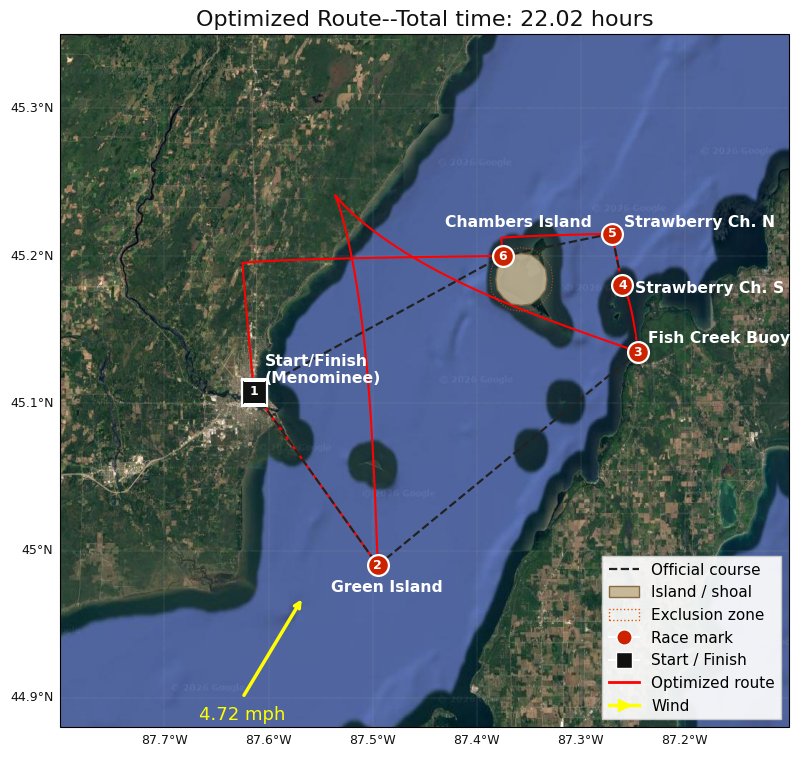

In [ ]:
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

PLATE = ccrs.PlateCarree()

ax = get_satellite_map()
total_time = 0

for i in range(1, 7):
    x, y = legs[i]['x'], legs[i]['y']
    ax.plot(x, y, transform=PLATE, color='r')
    total_time += legs[i]['T']

# Wind arrow — components in geographic degrees/hour, normalized for display
WX = 2.43 / (69.0 * np.cos(np.deg2rad(45.1025)))  # lon deg/hr
WY = 4.05 / 69.0                                    # lat deg/hr
scale = 0.09 / np.sqrt(WX**2 + WY**2)              # fixed arrow length ~0.12 deg
arrow_lon, arrow_lat = -87.625, 44.9               # top-left corner of map
ax.annotate('', 
            xy=(arrow_lon + WX * scale, arrow_lat + WY * scale),
            xytext=(arrow_lon, arrow_lat),
            xycoords=PLATE._as_mpl_transform(ax),
            textcoords=PLATE._as_mpl_transform(ax),
            arrowprops=dict(arrowstyle='->', color='yellow', lw=2.5),
            zorder=20)
ax.text(arrow_lon, arrow_lat - 0.015, '4.72 mph', fontsize=13, color='yellow',
        ha='center', transform=PLATE, zorder=20)

ax.set_title(f"Optimized Route--Total time: {(total_time / 2):.2f} hours", fontsize=16)

extra = [
    Line2D([0],[0], color='r', lw=2, label='Optimized route'),
    Line2D([0],[0], color='yellow', lw=2.5, marker='>', markersize=8,
           label=f'Wind'),
]
add_legend(ax, extra_handles=extra)



plt.savefig()


In [22]:
import importlib
import mapper

importlib.reload(mapper)
from mapper import get_satellite_map, add_legend


# Look Here Ethan

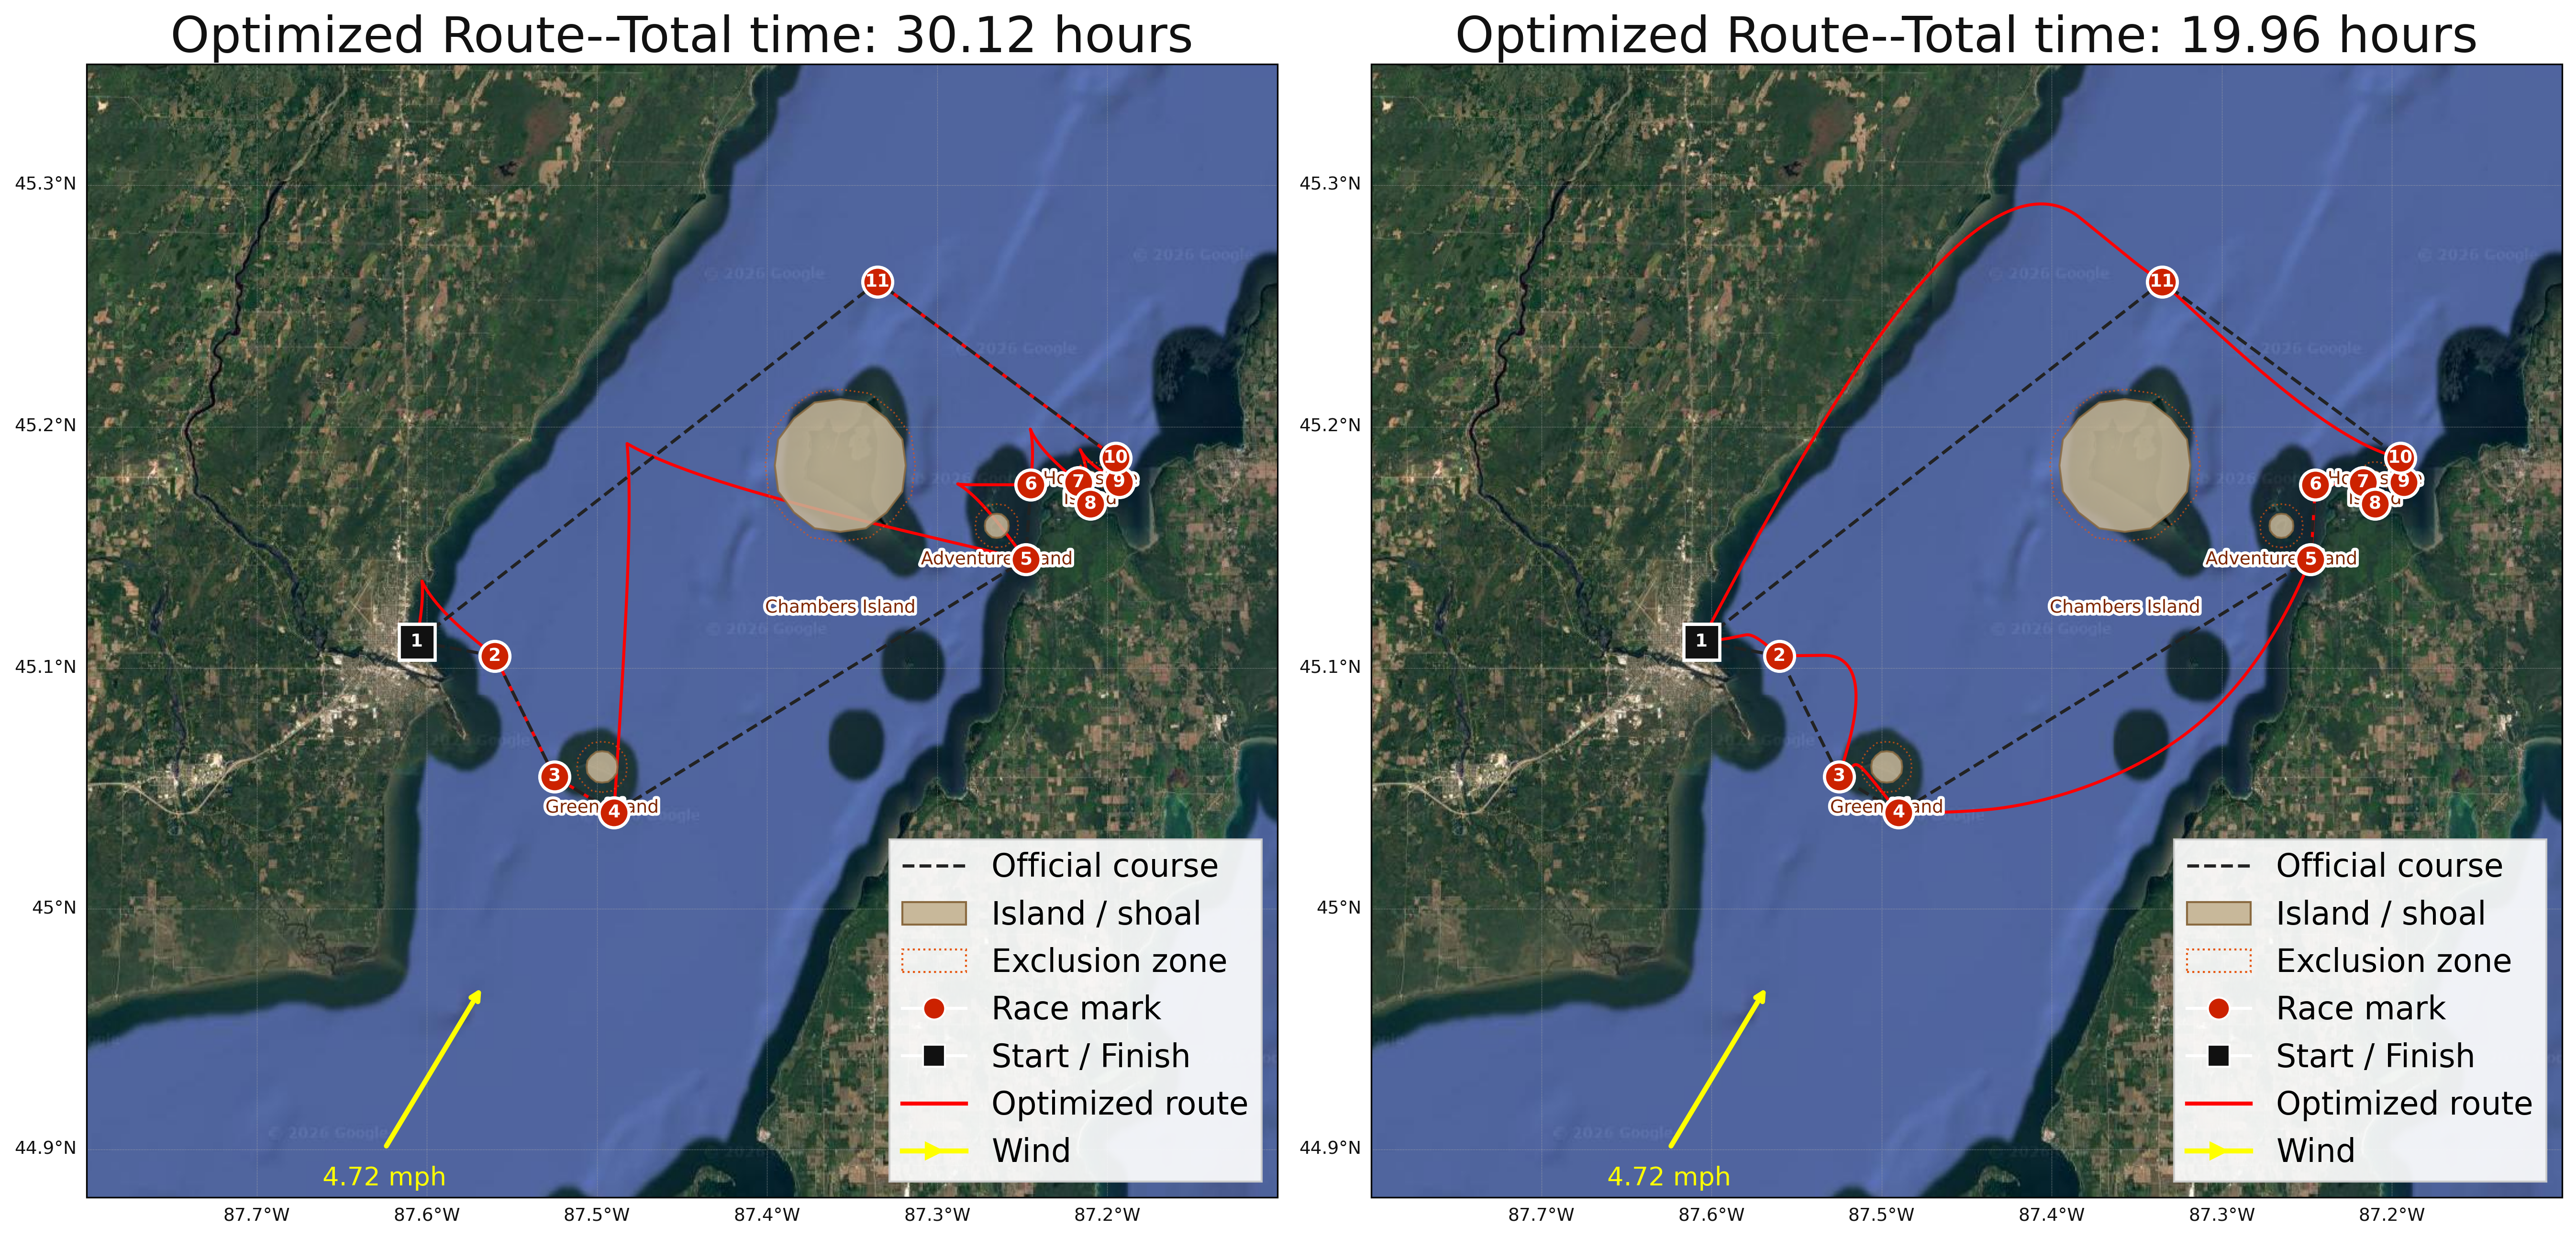

In [27]:
import h5py
from mapper import get_satellite_map, add_legend
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import cartopy.io.img_tiles as cimgt

models = ['vel', 'acc']
tiler = cimgt.GoogleTiles(style='satellite')   # swap to 'terrain' or 'street' if preferred
fig = plt.figure(figsize=(27, 9), dpi=300)

for j in range(2):
    legs = {}
    for leg in range(1, 12):
        with h5py.File(f'../data/{models[j]}_leg_{leg}.h5', 'r') as f:
            
            # # Read a dataset
            x = f['x'][:]  # [:] converts to numpy array
            y = f['y'][:]
            theta = f['theta'][:]
            T = f['T'][()]

            legs[leg] = {
                'x': x,
                'y': y,
                'theta': theta,
                'T': T
            }


    PLATE = ccrs.PlateCarree()

    ax = fig.add_subplot(1, 3, j + 1, projection=tiler.crs)
    ax = get_satellite_map(ax, clean=True)
    total_time = 0

    for i in range(1, 12):
        if models[j] == 'vel' and i == 11:
            break
        x, y = legs[i]['x'], legs[i]['y']
        ax.plot(x, y, transform=PLATE, color='r')
        total_time += legs[i]['T']

    # Wind arrow — components in geographic degrees/hour, normalized for display
    WX = 2.43 / (69.0 * np.cos(np.deg2rad(45.1025)))  # lon deg/hr
    WY = 4.05 / 69.0                                    # lat deg/hr
    scale = 0.09 / np.sqrt(WX**2 + WY**2)              # fixed arrow length ~0.12 deg
    arrow_lon, arrow_lat = -87.625, 44.9               # top-left corner of map
    ax.annotate('', 
                xy=(arrow_lon + WX * scale, arrow_lat + WY * scale),
                xytext=(arrow_lon, arrow_lat),
                xycoords=PLATE._as_mpl_transform(ax),
                textcoords=PLATE._as_mpl_transform(ax),
                arrowprops=dict(arrowstyle='->', color='yellow', lw=2.5),
                zorder=20)
    ax.text(arrow_lon, arrow_lat - 0.015, '4.72 mph', fontsize=13, color='yellow',
            ha='center', transform=PLATE, zorder=20)

    ax.set_title(f"Optimized Route--Total time: {(total_time):.2f} hours", fontsize=25)

    extra = [
        Line2D([0],[0], color='r', lw=2, label='Optimized route'),
        Line2D([0],[0], color='yellow', lw=2.5, marker='>', markersize=8,
            label=f'Wind'),
    ]
    add_legend(ax, extra_handles=extra)

plt.tight_layout()
plt.savefig('../../Paper/images/optimized_routes.png')

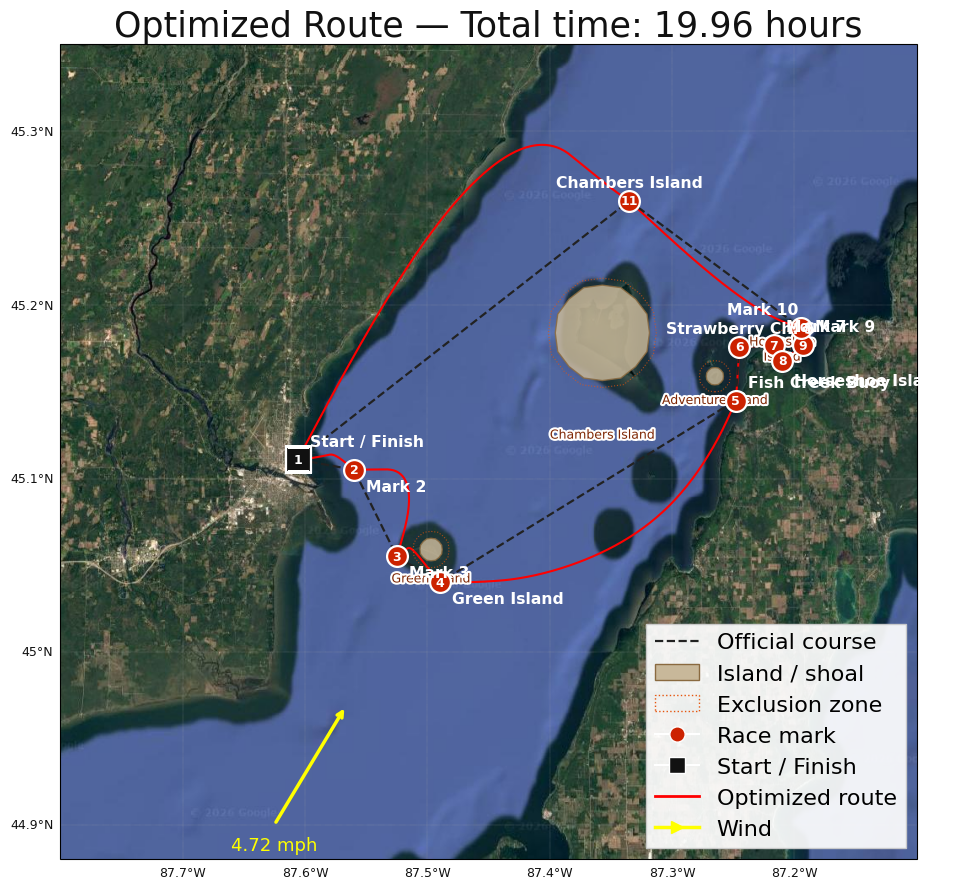

In [12]:
%load_ext autoreload
%autoreload 2

import h5py
from mapper import get_satellite_map, add_legend
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

legs = {}

for leg in range(1, 12):
    # with h5py.File(f'../data/acc_leg_{leg}.h5', 'r') as f:
    with h5py.File(f'../data/acc_leg_{leg}.h5', 'r') as f:
        x = f['x'][:]
        y = f['y'][:]
        theta = f['theta'][:]
        T = f['T'][()]

        legs[leg] = {
            'x': x,
            'y': y,
            'theta': theta,
            'T': T
        }


import numpy as np
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

PLATE = ccrs.PlateCarree()

ax = get_satellite_map()
total_time = 0

for i in range(1, 12):
    x, y = legs[i]['x'], legs[i]['y']
    ax.plot(x, y, transform=PLATE, color='r')
    total_time += legs[i]['T']

# Wind arrow — components in geographic degrees/hour, normalized for display
WX = 2.43 / (69.0 * np.cos(np.deg2rad(45.1025)))  # lon deg/hr
WY = 4.05 / 69.0                                    # lat deg/hr
scale = 0.09 / np.sqrt(WX**2 + WY**2)              # fixed arrow length ~0.12 deg
arrow_lon, arrow_lat = -87.625, 44.9               # bottom-left corner of map
ax.annotate('',
            xy=(arrow_lon + WX * scale, arrow_lat + WY * scale),
            xytext=(arrow_lon, arrow_lat),
            xycoords=PLATE._as_mpl_transform(ax),
            textcoords=PLATE._as_mpl_transform(ax),
            arrowprops=dict(arrowstyle='->', color='yellow', lw=2.5),
            zorder=20)
ax.text(arrow_lon, arrow_lat - 0.015, '4.72 mph', fontsize=13, color='yellow',
        ha='center', transform=PLATE, zorder=20)

ax.set_title(f"Optimized Route — Total time: {(total_time):.2f} hours", fontsize=25)

extra = [
    Line2D([0],[0], color='r', lw=2, label='Optimized route'),
    Line2D([0],[0], color='yellow', lw=2.5, marker='>', markersize=8, label='Wind'),
]
add_legend(ax, extra_handles=extra)

plt.tight_layout()
plt.savefig('optimized_route2.png')